In [1]:
print("""
=========================================================
Notebook 2 : Data Preprocessing

Tasks
------
1. Load Dataset
2. Remove unnecessary columns
3. Check Missing Values
4. Handle Missing Values
5. Remove Duplicates
6. Detect Outliers
7. Feature Scaling
8. Save Clean Dataset
=========================================================
""")


Notebook 2 : Data Preprocessing

Tasks
------
1. Load Dataset
2. Remove unnecessary columns
3. Check Missing Values
4. Handle Missing Values
5. Remove Duplicates
6. Detect Outliers
7. Feature Scaling
8. Save Clean Dataset



In [2]:
# =====================================
# Import Required Libraries
# =====================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# =====================================
# Read Dataset
# =====================================

df = pd.read_csv("../data/raw/dielectron.csv")

print("Dataset Loaded Successfully")

print(df.shape)

Dataset Loaded Successfully
(100000, 19)


In [4]:
df.head()

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.71410,-7.31132,10.531000,-57.29740,12.82020,-2.20267,2.17766,1,11.2836,-1.032340,-1.88066,-11.0778,2.14537,-2.344030,-2.072810,-1,8.94841
1,147115,366704169,6.61188,-4.15213,-0.579855,-5.11278,4.19242,-1.02842,-3.00284,-1,17.1492,-11.713500,5.04474,11.4647,12.75360,0.808077,2.734920,1,15.89300
2,147115,367112316,25.54190,-11.48090,2.041680,22.72460,11.66100,1.42048,2.96560,1,15.8203,-1.472800,2.25895,-15.5888,2.69667,-2.455080,2.148570,1,38.38770
3,147115,366952149,65.39590,7.51214,11.887100,63.86620,14.06190,2.21838,1.00721,1,25.1273,4.087860,2.59641,24.6563,4.84272,2.330210,0.565865,-1,3.72862
4,147115,366523212,61.45040,2.95284,-14.622700,-59.61210,14.91790,-2.09375,-1.37154,-1,13.8871,-0.277757,-2.42560,-13.6708,2.44145,-2.423700,-1.684810,-1,2.74718


In [5]:
missing_percent = (df.isnull().mean()) * 100

missing_percent.sort_values(ascending=False)

M        0.085
E2       0.000
Q2       0.000
phi2     0.000
eta2     0.000
pt2      0.000
pz2      0.000
py2      0.000
px2      0.000
Run      0.000
Event    0.000
phi1     0.000
eta1     0.000
pt1      0.000
pz1      0.000
py1      0.000
px1      0.000
E1       0.000
Q1       0.000
dtype: float64

In [6]:
# =====================================
# Handle Missing Values
# =====================================

if df.isnull().sum().sum() == 0:
    print("No Missing Values Found.")
else:
    df = df.fillna(df.median(numeric_only=True))
    print("Missing Values Filled.")

Missing Values Filled.


In [7]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 23


In [8]:
df = df.drop_duplicates()

print("New Shape :", df.shape)

New Shape : (99977, 19)


In [9]:
# =====================================
# Remove Identifier Columns
# =====================================

df = df.drop(columns=["Run", "Event"])

print(df.columns)

Index(['E1', 'px1 ', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'E2', 'px2',
       'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'M'],
      dtype='str')


In [10]:
X = df.drop(columns=["M"])

y = df["M"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (99977, 16)
Target Shape : (99977,)


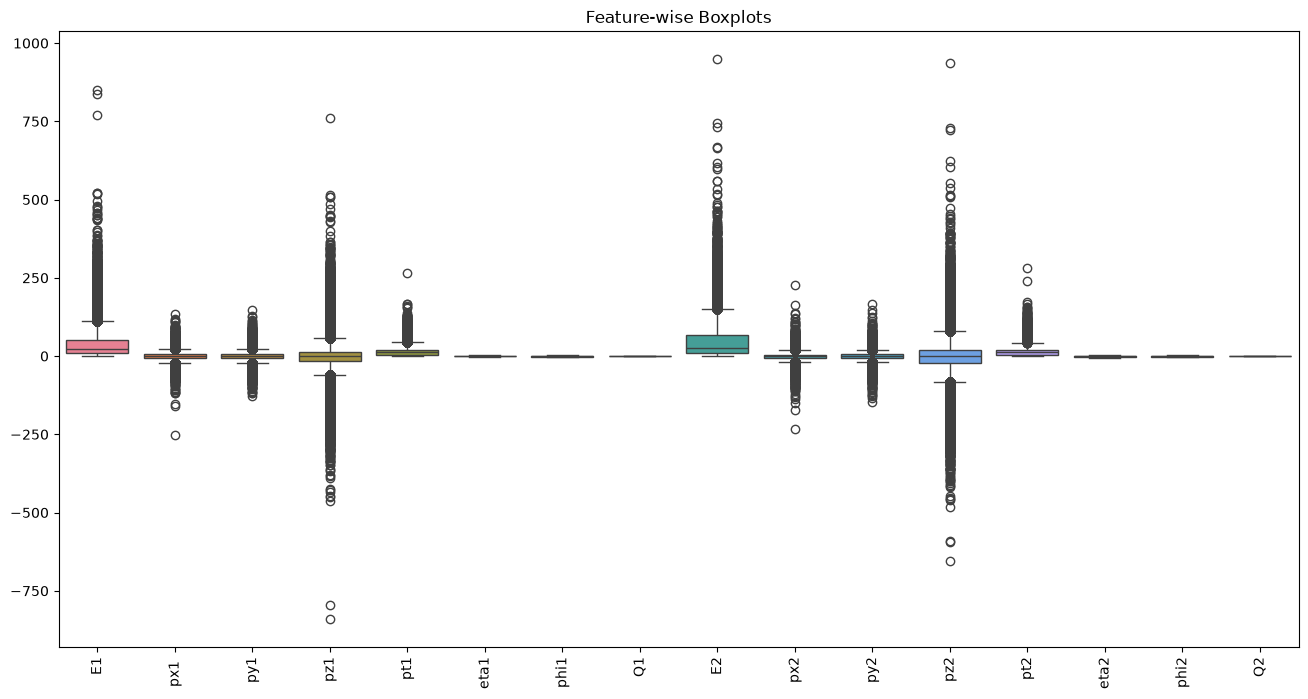

In [11]:
plt.figure(figsize=(16,8))

sns.boxplot(data=X)

plt.xticks(rotation=90)

plt.title("Feature-wise Boxplots")

plt.show()

In [12]:
# =====================================
# Feature Scaling
# =====================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2
0,0.540546,-0.555615,0.768226,-1.081096,-0.128473,-1.462574,1.198123,1.005466,-0.699886,-0.078375,-0.152238,-0.154462,-0.935515,-1.306746,-1.152546,-0.995758
1,-0.723642,-0.319934,-0.056596,-0.069794,-0.824877,-0.659474,-1.680643,-0.994564,-0.574426,-0.891997,0.373616,0.212487,-0.084210,0.506846,1.493534,1.004260
2,-0.264331,-0.866673,0.138016,0.469676,-0.222039,1.015392,1.635976,1.005466,-0.602850,-0.111926,0.162087,-0.227893,-0.891274,-1.370640,1.170818,1.004260
3,0.702670,0.550242,0.868897,1.266972,-0.028247,1.561096,0.547713,1.005466,-0.403780,0.311650,0.187711,0.427221,-0.719054,1.382619,0.299729,-0.995758
4,0.606938,0.210110,-1.099077,-1.125953,0.040846,-1.388081,-0.774142,-0.994564,-0.644199,-0.020895,-0.193616,-0.196671,-0.911755,-1.352585,-0.938998,-0.995758


In [13]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
E1,99977.0,9.097039e-17,1.000005,-0.874900,-0.678866,-0.357135,0.329549,19.754599
px1,99977.0,-6.680638e-18,1.000005,-18.704423,-0.400584,0.000357,0.416171,10.026677
py1,99977.0,-8.386333e-18,1.000005,-9.373115,-0.405318,-0.006209,0.405733,10.933769
pz1,99977.0,2.842825e-18,1.000005,-16.268465,-0.278103,0.023213,0.285285,14.759429
pt1,99977.0,-4.093668e-17,1.000005,-1.145547,-0.858923,-0.116583,0.452590,20.273261
eta1,99977.0,1.137130e-18,1.000005,-2.804922,-0.834217,0.001971,0.826574,1.837806
phi1,99977.0,-1.535125e-17,1.000005,-1.757740,-0.860630,0.007111,0.856194,1.733678
Q1,99977.0,-3.581959e-17,1.000005,-0.994564,-0.994564,-0.994564,1.005466,1.005466
E2,99977.0,2.183289e-16,1.000005,-0.931127,-0.704729,-0.400831,0.490278,19.343769
px2,99977.0,9.665604e-18,1.000005,-17.803798,-0.364958,-0.002400,0.367430,17.316811


In [14]:
processed_df = X_scaled.copy()

processed_df["M"] = y.values

processed_df.head()

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,0.540546,-0.555615,0.768226,-1.081096,-0.128473,-1.462574,1.198123,1.005466,-0.699886,-0.078375,-0.152238,-0.154462,-0.935515,-1.306746,-1.152546,-0.995758,8.94841
1,-0.723642,-0.319934,-0.056596,-0.069794,-0.824877,-0.659474,-1.680643,-0.994564,-0.574426,-0.891997,0.373616,0.212487,-0.084210,0.506846,1.493534,1.004260,15.89300
2,-0.264331,-0.866673,0.138016,0.469676,-0.222039,1.015392,1.635976,1.005466,-0.602850,-0.111926,0.162087,-0.227893,-0.891274,-1.370640,1.170818,1.004260,38.38770
3,0.702670,0.550242,0.868897,1.266972,-0.028247,1.561096,0.547713,1.005466,-0.403780,0.311650,0.187711,0.427221,-0.719054,1.382619,0.299729,-0.995758,3.72862
4,0.606938,0.210110,-1.099077,-1.125953,0.040846,-1.388081,-0.774142,-0.994564,-0.644199,-0.020895,-0.193616,-0.196671,-0.911755,-1.352585,-0.938998,-0.995758,2.74718


In [15]:
import os

# Create processed directory if it doesn't exist
os.makedirs("../data/processed", exist_ok=True)

processed_df.to_csv(
    "../data/processed/dielectron_processed.csv",
    index=False
)

print("Processed Dataset Saved Successfully")

Processed Dataset Saved Successfully


In [16]:
print("=" * 50)

print("Original Dataset Shape :", df.shape)

print("Processed Dataset Shape :", processed_df.shape)

print("Missing Values :", processed_df.isnull().sum().sum())

print("Duplicate Rows :", processed_df.duplicated().sum())

print("=" * 50)

Original Dataset Shape : (99977, 17)
Processed Dataset Shape : (99977, 17)
Missing Values : 0
Duplicate Rows : 0
